In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.special import hermite
from scipy.integrate import dblquad
import scipy as sp
from scipy import signal
from scipy.signal import butter, filtfilt
from tqdm import tqdm
from scipy.interpolate import interp1d

In [43]:
def analytical_integral_y(w0, w0_mode, n):
    if n % 2 == 1:
        return 0.0  # same as original early return

    p = n // 2
    q = 1/w0**2 + 1/w0_mode**2
    Delta = - (w0_mode**2 - w0**2) / (w0_mode**2 + w0**2)

    if p == 0:
        return float(np.sqrt(np.pi / q))  # handles n=0 and Delta=0 cleanly
    if Delta == 0.0:
        return 0.0  # Delta**p with p>0

    # sign and magnitude separately to avoid log of negative
    sign = -1.0 if (Delta < 0 and (p % 2 == 1)) else 1.0
    logmag = (0.5*math.log(math.pi / q)
              + math.lgamma(2*p + 1) - math.lgamma(p + 1)
              + p*math.log(abs(Delta)))
    return sign * math.exp(logmag)


def analytical_integral_x(w0: float,
                w0_mode: float,
                k: float,
                theta: float,
                m: int) -> complex:
    
    if m < 0 or int(m) != m:
        raise ValueError("m must be a non-negative integer")
    
    # Core scalars
    q      = 1.0 / w0**2 + 1.0 / w0_mode**2             # real, > 0
    s      = 1j * k * np.sin(theta)                     # purely imaginary
    alpha  = np.sqrt(2.0) / w0_mode
    Delta  = alpha**2 / q - 1.0                         # can be ±
    mu     = alpha * s / q

    # Prefactor  √(π/q)  exp(s² / 4q)  m!
    pref   = np.sqrt(np.pi / q) * np.exp(s**2 / (4.0 * q)) * math.factorial(m)

    # Finite series  Σ_{j=0}^{⌊m/2⌋}  Δ^j / j! · μ^{m-2j} / (m-2j)!
    series = 0.0 + 0.0j
    for j in range(m // 2 + 1):
        series += (Delta ** j) / math.factorial(j) * (mu ** (m - 2 * j)) / math.factorial(m - 2 * j)

    return pref * series

def c_mn(w0, w0_mode, k, theta, m, n):
    E0=np.sqrt(2/(np.pi * (w0)**2))
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    const = E0 * np.sqrt(2/denominator)
    return const * analytical_integral_x(w0, w0_mode, k, theta, m) * analytical_integral_y(w0, w0_mode, n)

# the waist as a function of z
def w(z, w0_mode, k):
    zR = k * w0_mode**2 / 2
    w_z = w0_mode * np.sqrt(1 + (z/zR)**2)
    return w_z

# the radius of curvature as a function of z
def R(z, w0_mode,  k):
    zR = k * w0_mode**2 / 2
    R_z = z * (1 + (zR/z)**2)
    return R_z

# the Guoy phase as a function of z
def psi(z, w0_mode, k, m = 0, n = 0):
    zR = k * w0_mode**2 / 2
    psi_z = (m + n + 1) * np.arctan2(z, zR)
    return psi_z

def u(x, y, z, w0_mode, k, m = 0, n = 0):
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    norm = np.sqrt(2/denominator)
    u = norm * w0_mode/w(z, w0_mode, k) * hermite(m)(np.sqrt(2) * x / w(z, w0_mode, k)) * hermite(n)(np.sqrt(2) * y / w(z, w0_mode, k)) * np.exp(-(x**2 + y**2)/w(z, w0_mode, k)**2) * np.exp(-1j * k * (x**2 + y**2)/(2 * R(z, w0_mode, k))) * np.exp(1j*psi(z, w0_mode, k, m, n)) * np.exp(-1j*k*z)
    return u

def UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size = 10):
    w0_new = 2 * f / (k * w0_mode)
    result = 0
    xi = z - 2 * f
    for m in range(basis_size):
        for n in range(basis_size):
            result += c_mn(w0, w0_mode, k, theta, m, n) * u(x, y, xi, w0_new, k, m, n)
    return result

def gaussian(x, y, w_gauss):
    #normalization constant
    const = np.sqrt(2/(np.pi * w_gauss**2))
    gaussian = const * np.exp(-(x**2 + y**2)/w_gauss**2)
    return gaussian

In [64]:
z = 0.4
w0 = 1.65e-6
w0_mode = w0
k = 2 * np.pi/488e-9
f = 5.5e-3
basis_size = 20
xi = z - 2 * f
w0_new = 2 * f / (k * w0_mode)
w_gauss = 0.35e-3
v_a = 3630 # acoustic velocity inside crystal is 3630 meters/second (Lead Molybdate (PbMoO4))
R_ap = 5.5 * w_gauss  # radius of AOM aperture (5.5 factor seems to match the experimental time the best)

# turn the transducer phase into a function via 1D linear interpolation
transducer_data = np.load("transducer_phase.npz")
time_tran = transducer_data["t"]
print(time_tran[-1])
phase_tran = transducer_data["phase"]
phase_func = interp1d(time_tran, phase_tran, kind='linear', bounds_error=False, fill_value = (0, 0))


def precompute_UEfz(A_func, R_ap, N=300):
    x = np.linspace(-R_ap, R_ap, N)
    y = np.linspace(-R_ap, R_ap, N)
    dx = dy = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing='ij')
    A_vals = A_func(X, Y)
    return A_vals, X, Y, dx, dy

def integrate_with_gaussian(A_vals, B_func, X, Y, dx, dy, clip_x, t, edge):
    if edge == 'rise':
        B_vals = B_func(X, Y)
        integrand = np.conj(A_vals) * B_vals * np.exp(1j * phase_func(t - (X + R_ap) / v_a))  # the extra exp function is supposed to represent the transducer phase in retarded time. ( * np.exp(1j * phase_func(t - (X + R_ap) / v_a)) )
        integrand[X >= clip_x] = 0
        return np.sum(integrand) * dx * dy
    elif edge == 'fall':
        B_vals = B_func(X, Y)
        integrand = np.conj(A_vals) * B_vals * np.exp(1j * phase_func(t - (X + R_ap) / v_a))
        integrand[X <= clip_x] = 0
        return np.sum(integrand) * dx * dy


x_array = np.array([-172.19360348510505, -144.36478761715603, -114.22776253998202, -94.48217121877249, -79.10407346189325, -64.89605401436572, -40.61653097010358, -33.510279820418916, -20.546797487079107, -6.71560973858467, 0, 12.984606147911517, 20.11731293740695, 34.74286706842302, 47.5560629826964, 57.842096073027484, 70.80300905098619,  84.71055495045277, 101.6203774617507, 114.25897813090194, 128.10864777096484])
theta_array = np.arctan2(x_array * 2.74e-6, 5.5e-3)
# x_array = np.array([-172.19360348510505, 0, 128.10864777096484])
# theta_array = np.arctan2(x_array * 2.74e-6, 5.5e-3)

# theta_array = np.array([0])


# The coordinate system is as follows: The Gaussian is centered at (0, 0). x=-R is the left edge of the AOM aperture, with the right edge at x = +R. The acoustic wave travels in the +x direction.
# t = 0 is the time at which the first tip of the acoustic wave reaches the left edge of the aperture. 
for i, theta in tqdm(enumerate(theta_array)):

    # Define the AOM Aperture size
    print(f"The back-propagated waist size is: {w(xi, w0_new, k)}")
    print(f"The Guassian waist size is {w_gauss}")
    total_time = 2 * (R_ap * 0.99) / v_a
    print(f"The total simulation time is: {total_time}")
    time_array = np.arange(0, total_time, 1e-9)
    np.save("time.npy", time_array)
    print("Saved")

    # Define the lambda functions only on the xy plane
    UEfz = lambda x, y: UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size)
    gaussianz = lambda x, y: gaussian(x, y, w_gauss)

    # Precompute the laser beam
    Uvals, X, Y, dx, dy = precompute_UEfz(UEfz, R_ap, N = 1000)

    # compute the phase as a function of time for this angle
    rise_angle_array = []
    fall_angle_array = []
    rise_amp_array = []
    fall_amp_array = []
    for time in time_array:
        clip_x = -R_ap * 0.99 + time * v_a
        # gaussianz is B_func here. 
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, time, edge = 'rise')
        rise_angle_array.append(np.angle(overlap))
        rise_amp_array.append(np.abs(overlap)**2)
    
    rise_angle_array = np.unwrap(rise_angle_array)
    rise_angle_array = rise_angle_array - rise_angle_array[-1]
    for time in time_array:
        clip_x = -R_ap * 0.99 + time * v_a
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, time, edge = 'fall')
        fall_angle_array.append(np.angle(overlap))
        fall_amp_array.append(np.abs(overlap)**2)
    fall_angle_array = np.unwrap(fall_angle_array)
    fall_angle_array = fall_angle_array - fall_angle_array[0]
    angle_array = np.unwrap(np.concatenate((rise_angle_array, fall_angle_array)))
    amp_array = np.concatenate((rise_amp_array, fall_amp_array))
    np.save(f"phase_tran_{i - 10}", angle_array)
    np.save(f"amp_tran_{i - 10}", amp_array)

    # compute the amplitude as a function of time for this angle
    # rise_amp_array = []
    # fall_amp_array = []
    # for time in time_array:
    #     clip_x = -R_ap + time * v_a
    #     overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, time, edge = 'rise')
    #     rise_amp_array.append(np.abs(overlap)**2)
    # rise_amp_array = rise_amp_array
    # for time in time_array:
    #     clip_x = -R_ap + time * v_a
    #     overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, time, edge = 'fall')
    #     fall_amp_array.append(np.abs(overlap)**2)
    # fall_amp_array = fall_amp_array
    # amp_array = np.concatenate((rise_amp_array, fall_amp_array))
    # np.save(f"amp_tran_{i-10}", amp_array)


1.9999e-07


0it [00:00, ?it/s]

The back-propagated waist size is: 0.0005307723100175284
The Guassian waist size is 0.00035
The total simulation time is: 1.0500000000000001e-06
Saved


1it [01:11, 71.56s/it]

The back-propagated waist size is: 0.0005307723100175284
The Guassian waist size is 0.00035
The total simulation time is: 1.0500000000000001e-06
Saved


...

19it [22:21, 69.07s/it]

The back-propagated waist size is: 0.0005307723100175284
The Guassian waist size is 0.00035
The total simulation time is: 1.0500000000000001e-06
Saved


20it [23:35, 70.35s/it]

The back-propagated waist size is: 0.0005307723100175284
The Guassian waist size is 0.00035
The total simulation time is: 1.0500000000000001e-06
Saved


21it [24:48, 70.87s/it]


1.9999e-07


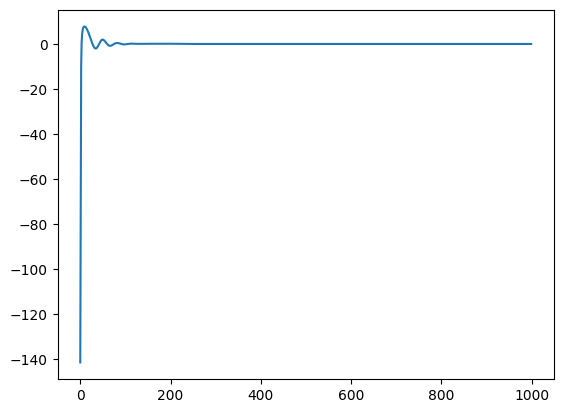

In [40]:
# turn the transducer phase into a function via 1D linear interpolation
transducer_data = np.load("transducer_phase.npz")
time_tran = transducer_data["t"]
print(time_tran[-1])
phase_tran = transducer_data["phase"]
phase_func = interp1d(time_tran, phase_tran, kind='linear', bounds_error= False, fill_value=(0, 0))

new_times = np.linspace(time_tran.min(), time_tran.max()*4, 1000)
interpolated_phases = phase_func(new_times)
plt.plot(interpolated_phases)

In [89]:
# off-center frequency 
raw115 = np.load("offcenter_frequency/115MHz.npz")
raw114 = np.load("offcenter_frequency/114MHz.npz")
raw113 = np.load("offcenter_frequency/113MHz.npz")
raw112 = np.load("offcenter_frequency/112MHz.npz")
raw111 = np.load("offcenter_frequency/111MHz.npz")
raw110 = np.load("offcenter_frequency/110MHz.npz")
raw109 = np.load("offcenter_frequency/109MHz.npz")
raw108 = np.load("offcenter_frequency/108MHz.npz")
raw107 = np.load("offcenter_frequency/107MHz.npz")
raw106 = np.load("offcenter_frequency/106MHz.npz")
raw105 = np.load("offcenter_frequency/105MHz.npz")

avg115 = np.mean(raw115['shots'], axis = 0)
avg114 = np.mean(raw114['shots'], axis = 0)
avg113 = np.mean(raw113['shots'], axis = 0)
avg112 = np.mean(raw112['shots'], axis = 0)
avg111 = np.mean(raw111['shots'], axis = 0)
avg110 = np.mean(raw110['shots'], axis = 0)
avg109 = np.mean(raw109['shots'], axis = 0)
avg108 = np.mean(raw108['shots'], axis = 0)
avg107 = np.mean(raw107['shots'], axis = 0)
avg106 = np.mean(raw106['shots'], axis = 0)
avg105 = np.mean(raw105['shots'], axis = 0)


In [90]:
def IQ_demodulation(data, f = 115e6, sample_rate = 1.0e9):
    omega = 2 * np.pi * f  # angular frequency in rad/s
    t_period = 1 / sample_rate
    t = np.arange(len(data)) * t_period

    # IQ demodulation
    I = data * np.cos(omega * t)
    Q = -data * np.sin(omega * t)

    # Define the low-pass filter
    def lowpass(signal, cutoff, fs, order=5):
        nyquist = fs / 2
        b, a = butter(order, cutoff / nyquist, btype='low')
        return filtfilt(b, a, signal)

    # Apply low-pass filter to I and Q
    cutoff = 0.2 * omega / (2 * np.pi) / 2  # convert rad/s to Hz
    Ilp = lowpass(I, cutoff, sample_rate)
    Qlp = lowpass(Q, cutoff, sample_rate)

    # Compute amplitude and phase
    amplitude = np.sqrt(Ilp**2 + Qlp**2)
    phase = np.unwrap(np.arctan2(Qlp, Ilp))

    # move phase to 0 reference
    number = phase[5000]
    phase = phase - number

    return amplitude, phase, t

def filter_waveform(amplitude_avg, phase_avg, t, type = 'percentage', absolute_threshold = 0.01, gradient_threshold = 1e-5):
    # mask1: filter on time
    mask1 = (t > 0.42e-5) & (t < 0.6e-5)
    amplitude = amplitude_avg[mask1]
    phase = phase_avg[mask1]
    t = t[mask1]
    
    if type == 'percentage':
        # mask2: filter on a certain percentage of max value
        index = np.where(phase == 0)
        # print(index)
        threshold = 0.05 * amplitude[index]
        mask2 = amplitude >  threshold
        # print(threshold)
        amplitude_filtered = amplitude[mask2]
        phase_filtered = phase[mask2]
        t_filtered = t[mask2]
    elif type == 'absolute':
        rise_start = np.argmax(amplitude > absolute_threshold)
        reversed_amplitude = amplitude[::-1]
        fall_end = len(amplitude) - np.argmax(np.abs(reversed_amplitude) > absolute_threshold) - 1
        amplitude_filtered = amplitude[rise_start:fall_end + 1]
        phase_filtered = phase[rise_start:fall_end + 1]
        t_filtered = t[rise_start:fall_end + 1]
    elif type == 'gradient':
        gradient = np.gradient(amplitude)
        rise_start = np.argmax(np.abs(gradient) > threshold)
        reversed_gradient = gradient[::-1]
        fall_end = len(amplitude) - np.argmax(np.abs(reversed_gradient) > threshold) - 1
        amplitude_filtered = amplitude[rise_start:fall_end + 1]
        phase_filtered = phase[rise_start:fall_end + 1]
        t_filtered = t[rise_start:fall_end + 1]
    return amplitude_filtered, phase_filtered, t_filtered

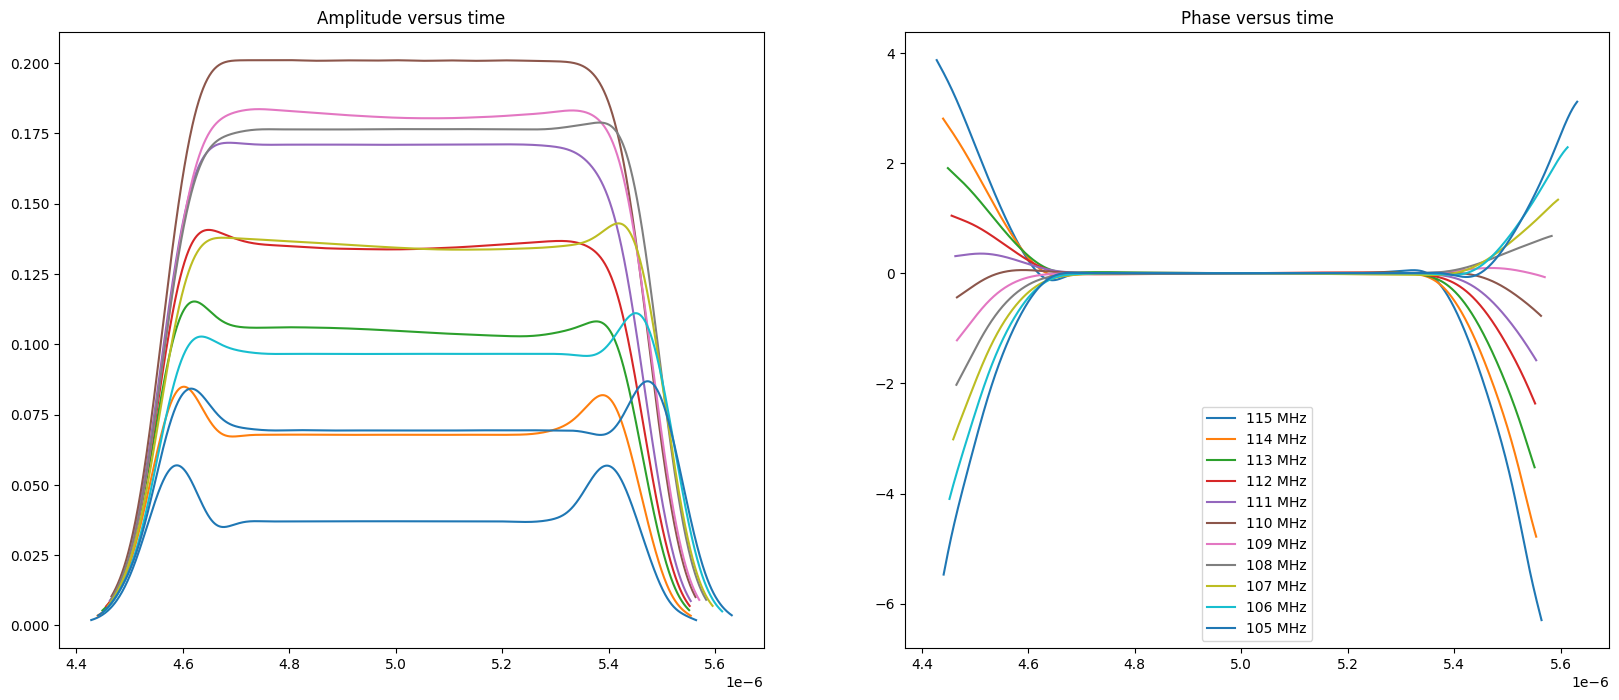

In [ ]:
amplitude115, phase115, t115 = IQ_demodulation(avg115, f=115e6)
amplitude114, phase114, t114 = IQ_demodulation(avg114, f=114e6)
amplitude113, phase113, t113 = IQ_demodulation(avg113, f=113e6)
amplitude112, phase112, t112 = IQ_demodulation(avg112, f=112e6)
amplitude111, phase111, t111 = IQ_demodulation(avg111, f=111e6)
amplitude110, phase110, t110 = IQ_demodulation(avg110, f=110e6)
amplitude109, phase109, t109 = IQ_demodulation(avg109, f=109e6)
amplitude108, phase108, t108 = IQ_demodulation(avg108, f=108e6)
amplitude107, phase107, t107 = IQ_demodulation(avg107, f=107e6)
amplitude106, phase106, t106 = IQ_demodulation(avg106, f=106e6)
amplitude105, phase105, t105 = IQ_demodulation(avg105, f=105e6)


amplitude115_filtered, phase115_filtered, t115_filtered = filter_waveform(amplitude115, phase115, t115)
amplitude114_filtered, phase114_filtered, t114_filtered = filter_waveform(amplitude114, phase114, t114)
amplitude113_filtered, phase113_filtered, t113_filtered = filter_waveform(amplitude113, phase113, t113)
amplitude112_filtered, phase112_filtered, t112_filtered = filter_waveform(amplitude112, phase112, t112)
amplitude111_filtered, phase111_filtered, t111_filtered = filter_waveform(amplitude111, phase111, t111)
amplitude110_filtered, phase110_filtered, t110_filtered = filter_waveform(amplitude110, phase110, t110)
amplitude109_filtered, phase109_filtered, t109_filtered = filter_waveform(amplitude109, phase109, t109)
amplitude108_filtered, phase108_filtered, t108_filtered = filter_waveform(amplitude108, phase108, t108)
amplitude107_filtered, phase107_filtered, t107_filtered = filter_waveform(amplitude107, phase107, t107)
amplitude106_filtered, phase106_filtered, t106_filtered = filter_waveform(amplitude106, phase106, t106)
amplitude105_filtered, phase105_filtered, t105_filtered = filter_waveform(amplitude105, phase105, t105)


fig, axs = plt.subplots(1, 2, figsize = (20, 8))

axs[0].plot(t115_filtered, amplitude115_filtered, label='115 MHz')
axs[0].plot(t114_filtered, amplitude114_filtered, label='114 MHz')
axs[0].plot(t113_filtered, amplitude113_filtered, label='113 MHz')
axs[0].plot(t112_filtered, amplitude112_filtered, label='112 MHz')
axs[0].plot(t111_filtered, amplitude111_filtered, label='111 MHz')
axs[0].plot(t110_filtered, amplitude110_filtered, label='110 MHz')
axs[0].plot(t109_filtered, amplitude109_filtered, label='109 MHz')
axs[0].plot(t108_filtered, amplitude108_filtered, label='108 MHz')
axs[0].plot(t107_filtered, amplitude107_filtered, label='107 MHz')
axs[0].plot(t106_filtered, amplitude106_filtered, label='106 MHz')
axs[0].plot(t105_filtered, amplitude105_filtered, label='105 MHz')
axs[0].set_title("Amplitude versus time")
axs[0].legend

axs[1].plot(t115_filtered, phase115_filtered, label='115 MHz')
axs[1].plot(t114_filtered, phase114_filtered, label='114 MHz')
axs[1].plot(t113_filtered, phase113_filtered, label='113 MHz')
axs[1].plot(t112_filtered, phase112_filtered, label='112 MHz')
axs[1].plot(t111_filtered, phase111_filtered, label='111 MHz')
axs[1].plot(t110_filtered, phase110_filtered, label='110 MHz')
axs[1].plot(t109_filtered, phase109_filtered, label='109 MHz')
axs[1].plot(t108_filtered, phase108_filtered, label='108 MHz')
axs[1].plot(t107_filtered, phase107_filtered, label='107 MHz')
axs[1].plot(t106_filtered, phase106_filtered, label='106 MHz')
axs[1].plot(t105_filtered, phase105_filtered, label='105 MHz')
axs[1].set_title("Phase versus time")
axs[1].legend()


In [102]:
# in this cell we calculate the change in angle 

def disp_angle(freq):
    delta_f = freq - 110e6
    bragg_error = 488e-9 * delta_f / 3630
    # distance between second mirror and the lens (estimate)
    dist = 0.2
    displacement_lens = dist * np.tan(bragg_error)
    displacement_fiber = f * np.tan(bragg_error)
    angle_fiber = np.arctan2((displacement_lens - displacement_fiber), f)
    return angle_fiber, displacement_fiber

angle_error_list = []
displacement_error_list = []

for i in [115e6, 114e6, 113e6, 112e6, 111e6, 110e6, 109e6, 108e6, 107e6, 106e6, 105e6]:
    angle_fiber, displacement_fiber = disp_angle(i)
    angle_error_list.append(angle_fiber)
    displacement_error_list.append(displacement_fiber)

print(angle_error_list)
print(displacement_error_list)



[0.02376612651895926, 0.019014188880161303, 0.014261392960885133, 0.009507953127706187, 0.004754083921626898, 0.0, -0.004754083921626898, -0.009507953127706187, -0.014261392960885133, -0.019014188880161303, -0.02376612651895926]
[3.6969702537593006e-06, 2.9575760426520163e-06, 2.218181938448359e-06, 1.478787914422408e-06, 7.393939438482553e-07, 0.0, -7.393939438482553e-07, -1.478787914422408e-06, -2.218181938448359e-06, -2.9575760426520163e-06, -3.6969702537593006e-06]


In [182]:

for i, theta in tqdm(enumerate(5 * np.array(angle_error_list))):
    # Define the lambda functions only on the xy plane
    UEfz = lambda x, y: UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size)
    gaussianz = lambda x, y: gaussian(x, y, w_gauss)

    # Precompute the laser beam
    Uvals, X, Y, dx, dy = precompute_UEfz(UEfz, L=max(4 * w(xi, w0_new, k), 4 *  w_gauss), N = 1000)

    total_time = 8 * w(xi, w0_new, k) / v_a
    print(total_time)
    time_array = np.arange(0, total_time, 1e-9)
    print(time_array.size)

    # compute the phase as a function of time for this angle
    rise_angle_array = []
    fall_angle_array = []
    for time in time_array:
        clip_x = -4 * w(xi, w0_new, k) + time * v_a
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, edge = 'rise')
        rise_angle_array.append(np.angle(overlap))
    # rise_angle_array = np.array(rise_angle_array)
    # rise_angle_array = rise_angle_array[rise_angle_array != 0]
    rise_angle_array = np.unwrap(rise_angle_array)
    rise_angle_array = rise_angle_array - rise_angle_array[-1]
    for time in time_array:
        clip_x = -4 * w(xi, w0_new, k) + time * v_a
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, edge = 'fall')
        fall_angle_array.append(np.angle(overlap))
    # fall_angle_array = np.array(fall_angle_array)
    # fall_angle_array = fall_angle_array[fall_angle_array != 0]
    fall_angle_array = np.unwrap(fall_angle_array)
    fall_angle_array = fall_angle_array - fall_angle_array[0]
    angle_array = np.unwrap(np.concatenate((rise_angle_array, fall_angle_array)))
    np.save(f"phase_{105+i}", angle_array)

    # compute the amplitude as a function of time for this angle
    rise_amp_array = []
    fall_amp_array = []
    for time in time_array:
        clip_x = -4 * w(xi, w0_new, k) + time * v_a
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, edge = 'rise')
        rise_amp_array.append(np.abs(overlap)**2)
    rise_amp_array = rise_amp_array
    for time in time_array:
        clip_x = -4 * w(xi, w0_new, k) + time * v_a
        overlap = integrate_with_gaussian(Uvals, gaussianz, X, Y, dx, dy, clip_x, edge = 'fall')
        fall_amp_array.append(np.abs(overlap)**2)
    fall_amp_array = fall_amp_array
    amp_array = np.concatenate((rise_amp_array, fall_amp_array))
    np.save(f"amp_{105+i}", amp_array)

0it [00:00, ?it/s]

1.1697461377796769e-06
1170


1it [01:04, 64.16s/it]

1.1697461377796769e-06
1170


2it [02:09, 64.87s/it]

...

9it [09:53, 66.31s/it]

1.1697461377796769e-06
1170


10it [10:59, 66.22s/it]

1.1697461377796769e-06
1170


11it [12:05, 65.94s/it]


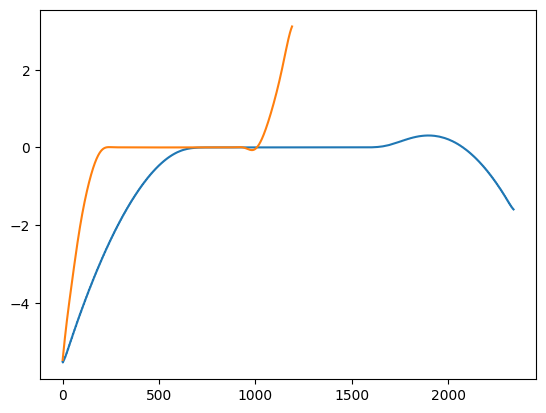

In [ ]:
phase115 = -np.load("z=0.2/phase_115.npy")
phase114 = -np.load("z=0.2/phase_114.npy")
phase113 = -np.load("z=0.2/phase_113.npy")
phase112 = -np.load("z=0.2/phase_112.npy")
phase111 = -np.load("z=0.2/phase_111.npy")
phase110 = -np.load("z=0.2/phase_110.npy")
phase109 = -np.load("z=0.2/phase_109.npy")
phase108 = -np.load("z=0.2/phase_108.npy")
phase107 = -np.load("z=0.2/phase_107.npy")
phase106 = -np.load("z=0.2/phase_106.npy")
phase105 = -np.load("z=0.2/phase_105.npy")



plt.plot(phase105)
# plt.plot(phase115)
plt.plot(phase105_filtered)


Some questions:
1. Determine direction of angle error theoretically, not just fitting to whatever works
2. Why does the experimental data show such big changes, suggesting bigger angle? Is it because the bragg angle error is incorrect, or is it because of the offset into the fiber which the model does not take into account.
3. There is supposedly an assymetry in the fall off in intensity due to the acoustic divergence, which also seems to affect the phase somehow. How do I take that into account in the model? 
4. What are the next steps, change central frequency and always realign? 
5. Why does the model not give efficiency 1 for perfect alignment? 


Below this point is obsolete code that I don't want to delete because there is a slight chance it may become useful.

In [ ]:
# --- Full script with c_mn precomputation (speedup #1 only) ---

import numpy as np
import math
from scipy.integrate import dblquad
from scipy.special import hermite

def analytical_integral_y(w0, w0_mode, n):
    if n % 2 == 1:
        return 0.0  # same as original early return

    p = n // 2
    q = 1/w0**2 + 1/w0_mode**2
    Delta = - (w0_mode**2 - w0**2) / (w0_mode**2 + w0**2)

    if p == 0:
        return float(np.sqrt(np.pi / q))  # handles n=0 and Delta=0 cleanly
    if Delta == 0.0:
        return 0.0  # Delta**p with p>0

    # sign and magnitude separately to avoid log of negative
    sign = -1.0 if (Delta < 0 and (p % 2 == 1)) else 1.0
    logmag = (0.5*math.log(math.pi / q)
              + math.lgamma(2*p + 1) - math.lgamma(p + 1)
              + p*math.log(abs(Delta)))
    return sign * math.exp(logmag)


def analytical_integral_x(w0: float,
                w0_mode: float,
                k: float,
                theta: float,
                m: int) -> complex:
    
    if m < 0 or int(m) != m:
        raise ValueError("m must be a non-negative integer")
    
    # Core scalars
    q      = 1.0 / w0**2 + 1.0 / w0_mode**2             # real, > 0
    s      = 1j * k * np.sin(theta)                     # purely imaginary
    alpha  = np.sqrt(2.0) / w0_mode
    Delta  = alpha**2 / q - 1.0                         # can be ±
    mu     = alpha * s / q

    # Prefactor  √(π/q)  exp(s² / 4q)  m!
    pref   = np.sqrt(np.pi / q) * np.exp(s**2 / (4.0 * q)) * math.factorial(m)

    # Finite series  Σ_{j=0}^{⌊m/2⌋}  Δ^j / j! · μ^{m-2j} / (m-2j)!
    series = 0.0 + 0.0j
    for j in range(m // 2 + 1):
        series += (Delta ** j) / math.factorial(j) * (mu ** (m - 2 * j)) / math.factorial(m - 2 * j)

    return pref * series

def c_mn(w0, w0_mode, k, theta, m, n):
    E0=np.sqrt(2/(np.pi * (w0)**2))
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    const = E0 * np.sqrt(2/denominator)
    return const * analytical_integral_x(w0, w0_mode, k, theta, m) * analytical_integral_y(w0, w0_mode, n)

# the waist as a function of z
def w(z, w0_mode, k):
    zR = k * w0_mode**2 / 2
    w_z = w0_mode * np.sqrt(1 + (z/zR)**2)
    return w_z

# the radius of curvature as a function of z
def R(z, w0_mode,  k):
    zR = k * w0_mode**2 / 2
    R_z = z * (1 + (zR/z)**2)
    return R_z

# the Guoy phase as a function of z
def psi(z, w0_mode, k, m = 0, n = 0):
    zR = k * w0_mode**2 / 2
    psi_z = (m + n + 1) * np.arctan2(z, zR)
    return psi_z

def u(x, y, z, w0_mode, k, m = 0, n = 0):
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    norm = np.sqrt(2/denominator)
    u_val = (norm * w0_mode/w(z, w0_mode, k)
             * hermite(m)(np.sqrt(2) * x / w(z, w0_mode, k))
             * hermite(n)(np.sqrt(2) * y / w(z, w0_mode, k))
             * np.exp(-(x**2 + y**2)/w(z, w0_mode, k)**2)
             * np.exp(-1j * k * (x**2 + y**2)/(2 * R(z, w0_mode, k)))
             * np.exp(1j*psi(z, w0_mode, k, m, n))
             * np.exp(-1j*k*z))
    return u_val

def UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size, C):
    """
    Same as original UE_f but uses precomputed modal coefficients C[m, n].
    """
    w0_new = 2 * f / (k * w0_mode)
    result = 0.0 + 0.0j
    xi = z - 2 * f
    for m in range(basis_size):
        for n in range(basis_size):
            # Use precomputed c_mn
            result += C[m, n] * u(x, y, xi, w0_new, k, m, n)
    return result

def compute_inner_product(A, B, L=100, tol=1e-8, clip_x=None):
    """
    Compute the inner product ∫∫ A*(x,y) B(x,y) dx dy over [-L, L] x [-L, L]
    using adaptive quadrature, with optional manual split at discontinuity x=clip_x.
    Assumes A and B are callable functions of (x, y) and decay exponentially.
    If clip_x is given and assumes B=0 for x > clip_x (Heaviside clip), integrates only x <= clip_x.

    Parameters:
    - A, B: callable functions, each taking (x, y) and returning complex or real.
    - L: float, half-width of integration limits (default 10.0).
    - tol: float, absolute/relative tolerance for quadrature (default 1e-8).
    - clip_x: float or None, x-location of discontinuity (default None for full integral).

    Returns:
    - complex: The approximated inner product.
    """
    
    def integrand_real(y, x):
        conj_A = np.conj(A(x, y))
        prod = conj_A * B(x, y)
        return np.real(prod)

    def integrand_imag(y, x):
        conj_A = np.conj(A(x, y))
        prod = conj_A * B(x, y)
        return np.imag(prod)

    # Determine x limits based on clip
    if clip_x is None:
        x_min, x_max = -L, L
    else:
        x_min, x_max = -L, min(clip_x, L)  # Integrate only x >= clip_x (assuming B=0 left)

    # Integrate real and imaginary parts separately
    real_part, real_err = dblquad(integrand_real, x_min, x_max, lambda x: -L, lambda x: L, epsabs=tol, epsrel=tol)
    imag_part, imag_err = dblquad(integrand_imag, x_min, x_max, lambda x: -L, lambda x: L, epsabs=tol, epsrel=tol)

    inner_product = real_part + 1j * imag_part
    total_err = real_err + imag_err  # Rough error estimate (magnitude)

    print(f"Estimated error: {total_err:.2e}")
    return inner_product

def clipped_gaussian(x, y, w_gauss, clip_x):
    # normalization constant
    const = np.sqrt(2/(np.pi * w_gauss**2))
    gaussian = const * np.exp(-(x**2 + y**2)/w_gauss**2)
    return gaussian

# ------------------ Parameters & execution ------------------

z = 0.4
w0 = 1.65e-6
w0_mode = 1.65e-6
k = 2 * np.pi/488e-9
theta = 0
f = 5.5e-3
basis_size = 20
xi = z - 2 * f
w0_new = 2 * f / (k * w0_mode)
print("w0_new =", w0_new)
clip_x = -0.25e-3
w_gauss = 0.35e-3

# --- NEW: precompute c_mn for the chosen basis_size ---
C = np.empty((basis_size, basis_size), dtype=complex)
for m in range(basis_size):
    for n in range(basis_size):
        C[m, n] = c_mn(w0, w0_mode, k, theta, m, n)

print("Precomputation complete")

UE_f_z = lambda x, y: UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size, C)
clipped_gaussian_z = lambda x, y: clipped_gaussian(x, y, w_gauss, clip_x)

print("w(xi, w0_new, k) =", w(xi, w0_new, k))

# Compute with split at clip_x (kept identical to your original: the clipping limits are commented out)
result = compute_inner_product(UE_f_z, clipped_gaussian_z, L=max(3 * w(xi, w0_new, k), 3 *  w_gauss), clip_x=clip_x)
print(f"Inner product: {result}")

In [ ]:
-0.35 = 0.02586190869989755+0.032278158648303946j  (~4.5 min)
-0.3 = 0.043410506389276765+0.05120992707816524j  (~9.5 min)
-0.25 = 0.06893660611397061+0.07746773510047511j  (~14.5 min)